<a href="https://colab.research.google.com/github/MorganDiaz2513892022/Caso-Practico/blob/main/notebook/Cluster_MorganAlejandroDiazGarcia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#librerias
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
#carga de la data
df = pd.read_csv(
    "https://raw.githubusercontent.com/MorganDiaz2513892022/Caso-Practico/refs/heads/main/dataset/Prestige_modificado.csv",
    sep=';'
)

In [ ]:
print("===== PRIMEROS REGISTROS =====")
print(df.head())


===== PRIMEROS REGISTROS =====
            occupation  education  income  women  prestige  census  type_num
0   gov.administrators      13.11   12351  11.16      68.8    1113         1
1     general.managers      12.26   25879   4.02      69.1    1130         1
2          accountants      12.77    9271  15.70      63.4    1171         1
3  purchasing.officers      11.42    8865   9.11      56.8    1175         1
4             chemists      14.62    8403  11.68      73.5    2111         1


In [ ]:
# Validacion

print("\n===== DIMENSIONES =====")
print(df.shape)

print("\n===== INFORMACIÓN GENERAL =====")
print(df.info())

print("\n===== VALORES NULOS =====")
print(df.isnull().sum())

print("\n===== DUPLICADOS =====")
print(df.duplicated().sum())

print("\n===== ESTADÍSTICA DESCRIPTIVA =====")
print(df.describe())




===== DIMENSIONES =====
(102, 7)

===== INFORMACIÓN GENERAL =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  102 non-null    object 
 1   education   102 non-null    float64
 2   income      102 non-null    int64  
 3   women       102 non-null    float64
 4   prestige    102 non-null    float64
 5   census      102 non-null    int64  
 6   type_num    102 non-null    int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 5.7+ KB
None

===== VALORES NULOS =====
occupation    0
education     0
income        0
women         0
prestige      0
census        0
type_num      0
dtype: int64

===== DUPLICADOS =====
0

===== ESTADÍSTICA DESCRIPTIVA =====
        education        income       women    prestige       census  \
count  102.000000    102.000000  102.000000  102.000000   102.000000   
mean    10.738039   6797.901961   

In [ ]:
# variables para clusterizacion
columnas_cluster = [
    'education',
    'income',
    'women',
    'prestige'
]

X = df[columnas_cluster].copy()

In [ ]:
#Escalamiento de datos

escalador = StandardScaler()

X_escalado = escalador.fit_transform(X)


In [ ]:
#Modelo de KMEANS con K4

modelo_k4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster_4'] = modelo_k4.fit_predict(X_escalado)


In [ ]:
#Modelo de K-MEANS CON K5
modelo_k5 = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster_5'] = modelo_k5.fit_predict(X_escalado)

In [ ]:
#Promedios para cluster
print("\n===== MODELO K=4 =====")

centroides_k4 = (
    df.groupby('Cluster_4')[columnas_cluster]
    .mean()
    .round(2)
)

print(centroides_k4)


print("\n===== MODELO K=5 =====")

centroides_k5 = (
    df.groupby('Cluster_5')[columnas_cluster]
    .mean()
    .round(2)
)

print(centroides_k5)




===== MODELO K=4 =====
           education    income  women  prestige
Cluster_4                                      
0               8.52   5599.02   9.77     35.17
1              14.69  15746.83   6.00     74.23
2              10.05   3395.95  76.66     37.73
3              13.08   7482.85  30.27     60.73

===== MODELO K=5 =====
           education    income  women  prestige
Cluster_5                                      
0               9.93   3337.95  75.73     36.44
1              10.70   7661.44   9.28     49.22
2              14.73  15338.00   7.44     73.85
3              14.17   6723.85  53.79     65.96
4               7.94   4629.50  11.39     30.90


In [ ]:
#Evaluacion del modelo
#SILHOUETTE SCORE

print("\n===== SILHOUETTE SCORE =====")

silhouette_k4 = silhouette_score(
    X_escalado,
    df['Cluster_4']
)

silhouette_k5 = silhouette_score(
    X_escalado,
    df['Cluster_5']
)

print("Silhouette K=4:", round(silhouette_k4, 3))
print("Silhouette K=5:", round(silhouette_k5, 3))


===== SILHOUETTE SCORE =====
Silhouette K=4: 0.379
Silhouette K=5: 0.375


In [ ]:
#Identificar Cluster con mayor prestigio

cluster_mayor_prestigio = (
    centroides_k4['prestige']
    .idxmax()
)

print("\n===== CLUSTER DE MAYOR PRESTIGIO =====")

print(
    "Cluster con mayor prestigio:",
    cluster_mayor_prestigio
)




===== CLUSTER DE MAYOR PRESTIGIO =====
Cluster con mayor prestigio: 1


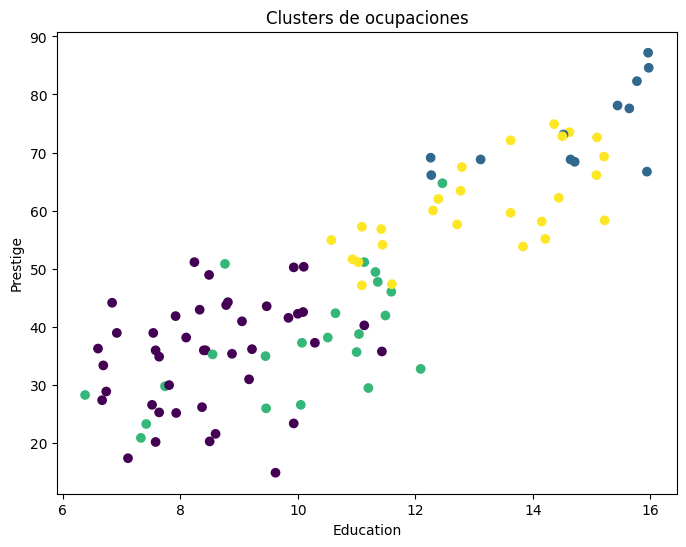

In [ ]:
#Visualizacion de clusters
plt.figure(figsize=(8,6))

plt.scatter(
    df['education'],
    df['prestige'],
    c=df['Cluster_4']
)

plt.xlabel('Education')
plt.ylabel('Prestige')
plt.title('Clusters de ocupaciones')

plt.show()


In [ ]:
#Exportar resultados

df.to_csv(
    "ocupaciones_clusterizadas.csv",
    index=False
)

print("\nArchivo exportado correctamente.")